# <b>1 <span style='color:#4285f4'>|</span> Importing libraries</b>
- **For ML Models**: Tensorflow, keras
- **For Data Manipulation**: numpy, pandas, sklearn
- **For Data Visualization**: matplotlib, seaborn,plotly

In [42]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFE
warnings.filterwarnings('ignore')

# <b>2 <span style='color:#4285f4'>|</span> Reading the Dataset</b>

In [43]:
df = pd.read_csv('vitals_datatimeu.csv')


In [44]:
# df types
df.dtypes

Row             int64
Skin_temp     float64
Heart_rate      int64
SPO2          float64
Target         object
dtype: object

# <b>3 <span style='color:#4285f4'>|</span> EDA </b>

In [45]:
df.head()

,Row,Skin_temp,Heart_rate,SPO2,Target
0,1,34.7,93,100.000000,Normal
1,2,35.1,95,99.845004,Normal
2,3,35.4,98,99.652965,Normal
3,4,35.7,99,99.418279,Normal
4,5,36.0,100,99.106790,Normal


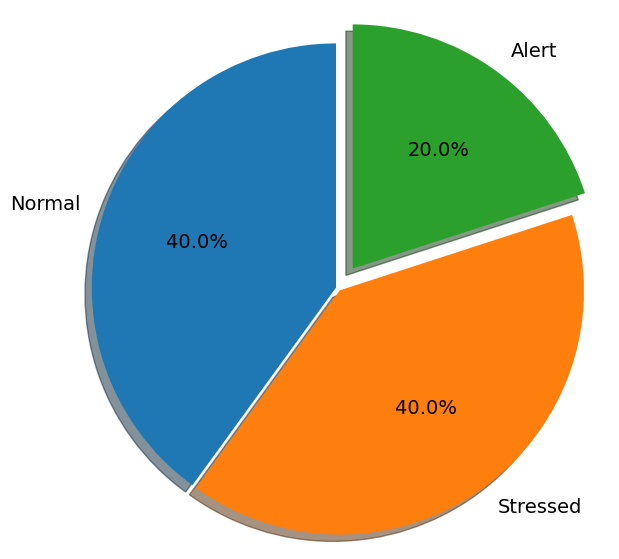

In [46]:
#  make a piechart of the Target column

# Pie chart, where the slices will be ordered and plotted counter-clockwise:
labels = df['Target'].value_counts().index
sizes = df['Target'].value_counts().values
explode = (0.01, 0.01, 0.1)  # only "explode" the 2nd slice (i.e. 'Hogs')

fig1, ax1 = plt.subplots(figsize=(7, 7))
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 14})
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



# <b>3 <span style='color:#4285f4'>|</span> Preprocessing </b>

In [47]:
import datetime

df = df.rename(columns={'Row': 'Timestamp'})

In [48]:
# Define the reference point for time
start_time = datetime.datetime(2023, 6, 27, 0, 0, 0)  # Adjust the date and time according to your data

# Convert the integer values to timestamps
df['Timestamp'] = df['Timestamp'].apply(lambda x: start_time + datetime.timedelta(seconds=x))

# Verify the converted timestamps
print(df['Timestamp'])

# make the timestamp column as index
df.set_index('Timestamp', inplace=True)



0      2023-06-27 00:00:01
1      2023-06-27 00:00:02
2      2023-06-27 00:00:03
3      2023-06-27 00:00:04
4      2023-06-27 00:00:05
               ...        
1795   2023-06-27 00:30:26
1796   2023-06-27 00:30:27
1797   2023-06-27 00:30:28
1798   2023-06-27 00:30:29
1799   2023-06-27 00:30:30
Name: Timestamp, Length: 1800, dtype: datetime64[ns]


In [49]:
# make histogram for timestamp with Heart_rate column

fig = px.histogram(df, x="SPO2", y="Heart_rate", color="Target", marginal="rug",
                     hover_data=df.columns)
fig.show()


## Are there any missing values?

In [50]:
print(df.isnull().values.any())


False


In [51]:
df.head()

,Skin_temp,Heart_rate,SPO2,Target
Timestamp,,,,
2023-06-27 00:00:01,34.7,93,100.000000,Normal
2023-06-27 00:00:02,35.1,95,99.845004,Normal
2023-06-27 00:00:03,35.4,98,99.652965,Normal
2023-06-27 00:00:04,35.7,99,99.418279,Normal
2023-06-27 00:00:05,36.0,100,99.106790,Normal


### If there's missing values, replace with average between neighbouring values:

In [52]:
# Check for null values
if df.isnull().values.any():
    # Replace null values with average of neighboring values
    df['Timestamp'] = df['Timestamp'].fillna((df['Timestamp'].shift() + df['Timestamp'].shift(-1)) / 2)


<Axes: >

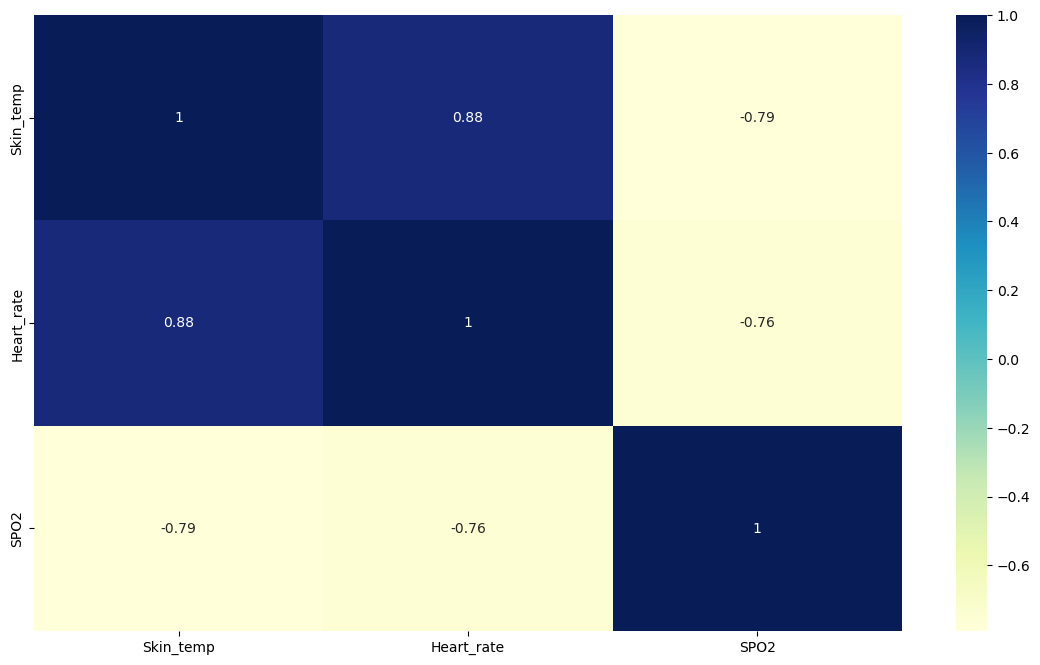

In [53]:
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(), annot=True, cmap="YlGnBu")

# <b>3 <span style='color:#4285f4'>|</span> OUTLIERS </b>

In [54]:
# Delete outliers:
# Delete all heart rate values above 250
df = df.drop(df[df['Heart_rate']>250].index)
# Delete all heart rate values below 40
df = df.drop(df[df['Heart_rate']<20].index)
# Delete all SPO2 values BELOW 75
df = df.drop(df[df['SPO2']<75].index)
# Delete all SPO2 values ABOVE 100
df = df.drop(df[df['SPO2']>100].index)
# Delete all temperature values BELOW 25
df = df.drop(df[df['Skin_temp']<25].index)
# Delete all temperature values ABOVE 50
df = df.drop(df[df['Skin_temp']>50].index)


## Hot encoding for categorical data

In [55]:
encoded_data = pd.get_dummies(df, columns=['Target'])


# <b>3-2 <span style='color:#4285f4'>|</span> Encoding data </b>

In [56]:
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])

Hot

In [57]:
df.dtypes

Skin_temp     float64
Heart_rate      int64
SPO2          float64
Target          int32
dtype: object

In [58]:
df

,Skin_temp,Heart_rate,SPO2,Target
Timestamp,,,,
2023-06-27 00:00:01,34.7,93,100.000000,1
2023-06-27 00:00:02,35.1,95,99.845004,1
2023-06-27 00:00:03,35.4,98,99.652965,1
2023-06-27 00:00:04,35.7,99,99.418279,1
2023-06-27 00:00:05,36.0,100,99.106790,1
...,...,...,...,...
2023-06-27 00:30:26,38.0,167,90.317728,0
2023-06-27 00:30:27,38.0,167,90.317728,0
2023-06-27 00:30:28,38.0,167,90.317728,0


# <b>4 <span style='color:#4285f4'>|</span> Splitting data </b>

In [59]:
X = df.drop(['Target'], axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# <b>5 <span style='color:#4285f4'>|</span> Scaling the data </b>

In [60]:
# use robust scaler to scale the data
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# <b>6 <span style='color:#4285f4'>|</span> ML Models </b>

## Table of models and their scores

In [61]:
from prettytable import PrettyTable
x = PrettyTable()
x.field_names = ["Model", "Train Score", "Test Score", "R2 Score", "Mean Absolute Error", "Mean Squared Error"]

# <b>6.1 <span style='color:#4285f4'>|</span> Lasso regression </b>

In [62]:
lasso = Lasso()
lasso.fit(X_train, y_train)
lasso_train_score = lasso.score(X_train, y_train)
lasso_test_score = lasso.score(X_test, y_test)
lasso_r2_score = r2_score(y_test, lasso.predict(X_test))
lasso_mae = mean_absolute_error(y_test, lasso.predict(X_test))
lasso_mse = mean_squared_error(y_test, lasso.predict(X_test))
x.add_row(["Lasso Regression", lasso_train_score, lasso_test_score, lasso_r2_score, lasso_mae, lasso_mse])

print(x)


+------------------+-------------+-----------------------+-----------------------+---------------------+--------------------+
|      Model       | Train Score |       Test Score      |        R2 Score       | Mean Absolute Error | Mean Squared Error |
+------------------+-------------+-----------------------+-----------------------+---------------------+--------------------+
| Lasso Regression |     0.0     | -0.002355768098188493 | -0.002355768098188493 |  0.6599176954732511 | 0.5836625514403293 |
+------------------+-------------+-----------------------+-----------------------+---------------------+--------------------+


# <b>6.2 <span style='color:#4285f4'>|</span>  Linear Regression </b>

In [63]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_train_score = lr.score(X_train, y_train)
lr_test_score = lr.score(X_test, y_test)
lr_r2_score = r2_score(y_test, lr.predict(X_test))
lr_mae = mean_absolute_error(y_test, lr.predict(X_test))
lr_mse = mean_squared_error(y_test, lr.predict(X_test))
x.add_row(["Linear Regression", lr_train_score, lr_test_score, lr_r2_score, lr_mae, lr_mse])

print(x)


+-------------------+-------------------+-----------------------+-----------------------+---------------------+---------------------+
|       Model       |    Train Score    |       Test Score      |        R2 Score       | Mean Absolute Error |  Mean Squared Error |
+-------------------+-------------------+-----------------------+-----------------------+---------------------+---------------------+
|  Lasso Regression |        0.0        | -0.002355768098188493 | -0.002355768098188493 |  0.6599176954732511 |  0.5836625514403293 |
| Linear Regression | 0.599567999531389 |   0.5995399483166153  |   0.5995399483166153  |  0.3393923666617911 | 0.23318420759818925 |
+-------------------+-------------------+-----------------------+-----------------------+---------------------+---------------------+


# <b>6.3 <span style='color:#4285f4'>|</span> Ridge regression </b>

In [64]:
ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_train_score = ridge.score(X_train, y_train)
ridge_test_score = ridge.score(X_test, y_test)
ridge_r2_score = r2_score(y_test, ridge.predict(X_test))
ridge_mae = mean_absolute_error(y_test, ridge.predict(X_test))
ridge_mse = mean_squared_error(y_test, ridge.predict(X_test))
x.add_row(["Ridge Regression", ridge_train_score, ridge_test_score, ridge_r2_score, ridge_mae, ridge_mse])

print(x)

+-------------------+--------------------+-----------------------+-----------------------+---------------------+---------------------+
|       Model       |    Train Score     |       Test Score      |        R2 Score       | Mean Absolute Error |  Mean Squared Error |
+-------------------+--------------------+-----------------------+-----------------------+---------------------+---------------------+
|  Lasso Regression |        0.0         | -0.002355768098188493 | -0.002355768098188493 |  0.6599176954732511 |  0.5836625514403293 |
| Linear Regression | 0.599567999531389  |   0.5995399483166153  |   0.5995399483166153  |  0.3393923666617911 | 0.23318420759818925 |
|  Ridge Regression | 0.5995186703710609 |   0.5989296400828958  |   0.5989296400828958  | 0.34179993822341836 | 0.23353958447354117 |
+-------------------+--------------------+-----------------------+-----------------------+---------------------+---------------------+


# <b>6.4 <span style='color:#4285f4'>|</span> Ada Boost regressor </b>

In [65]:
abr = AdaBoostRegressor()
abr.fit(X_train, y_train)
abr_train_score = abr.score(X_train, y_train)
abr_test_score = abr.score(X_test, y_test)
abr_r2_score = r2_score(y_test, abr.predict(X_test))
abr_mae = mean_absolute_error(y_test, abr.predict(X_test))
abr_mse = mean_squared_error(y_test, abr.predict(X_test))
x.add_row(["Ada Boost Regressor", abr_train_score, abr_test_score, abr_r2_score, abr_mae, abr_mse])

print(x)

+---------------------+--------------------+-----------------------+-----------------------+---------------------+---------------------+
|        Model        |    Train Score     |       Test Score      |        R2 Score       | Mean Absolute Error |  Mean Squared Error |
+---------------------+--------------------+-----------------------+-----------------------+---------------------+---------------------+
|   Lasso Regression  |        0.0         | -0.002355768098188493 | -0.002355768098188493 |  0.6599176954732511 |  0.5836625514403293 |
|  Linear Regression  | 0.599567999531389  |   0.5995399483166153  |   0.5995399483166153  |  0.3393923666617911 | 0.23318420759818925 |
|   Ridge Regression  | 0.5995186703710609 |   0.5989296400828958  |   0.5989296400828958  | 0.34179993822341836 | 0.23353958447354117 |
| Ada Boost Regressor |        1.0         |          1.0          |          1.0          |         0.0         |         0.0         |
+---------------------+------------------

# <b>6.5 <span style='color:#4285f4'>|</span> Gradient Boosting Regressor </b>

In [66]:
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)
gbr_train_score = gbr.score(X_train, y_train)
gbr_test_score = gbr.score(X_test, y_test)
gbr_r2_score = r2_score(y_test, gbr.predict(X_test))
gbr_mae = mean_absolute_error(y_test, gbr.predict(X_test))
gbr_mse = mean_squared_error(y_test, gbr.predict(X_test))
x.add_row(["Gradient Boosting Regressor", gbr_train_score, gbr_test_score, gbr_r2_score, gbr_mae, gbr_mse])

print(x)


+-----------------------------+--------------------+-----------------------+-----------------------+------------------------+------------------------+
|            Model            |    Train Score     |       Test Score      |        R2 Score       |  Mean Absolute Error   |   Mean Squared Error   |
+-----------------------------+--------------------+-----------------------+-----------------------+------------------------+------------------------+
|       Lasso Regression      |        0.0         | -0.002355768098188493 | -0.002355768098188493 |   0.6599176954732511   |   0.5836625514403293   |
|      Linear Regression      | 0.599567999531389  |   0.5995399483166153  |   0.5995399483166153  |   0.3393923666617911   |  0.23318420759818925   |
|       Ridge Regression      | 0.5995186703710609 |   0.5989296400828958  |   0.5989296400828958  |  0.34179993822341836   |  0.23353958447354117   |
|     Ada Boost Regressor     |        1.0         |          1.0          |          1.0     

# <b>6.6 <span style='color:#4285f4'>|</span> Random Forest Regressor </b>

In [67]:
rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)
rfr_train_score = rfr.score(X_train, y_train)
rfr_test_score = rfr.score(X_test, y_test)
rfr_r2_score = r2_score(y_test, rfr.predict(X_test))
rfr_mae = mean_absolute_error(y_test, rfr.predict(X_test))
rfr_mse = mean_squared_error(y_test, rfr.predict(X_test))
x.add_row(["Random Forest Regressor", rfr_train_score, rfr_test_score, rfr_r2_score, rfr_mae, rfr_mse])

print(x)


+-----------------------------+--------------------+-----------------------+-----------------------+------------------------+------------------------+
|            Model            |    Train Score     |       Test Score      |        R2 Score       |  Mean Absolute Error   |   Mean Squared Error   |
+-----------------------------+--------------------+-----------------------+-----------------------+------------------------+------------------------+
|       Lasso Regression      |        0.0         | -0.002355768098188493 | -0.002355768098188493 |   0.6599176954732511   |   0.5836625514403293   |
|      Linear Regression      | 0.599567999531389  |   0.5995399483166153  |   0.5995399483166153  |   0.3393923666617911   |  0.23318420759818925   |
|       Ridge Regression      | 0.5995186703710609 |   0.5989296400828958  |   0.5989296400828958  |  0.34179993822341836   |  0.23353958447354117   |
|     Ada Boost Regressor     |        1.0         |          1.0          |          1.0     

# <b>6.7 <span style='color:#4285f4'>|</span> Decision Tree Regressor </b>

In [68]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)
dtr_train_score = dtr.score(X_train, y_train)
dtr_test_score = dtr.score(X_test, y_test)
dtr_r2_score = r2_score(y_test, dtr.predict(X_test))
dtr_mae = mean_absolute_error(y_test, dtr.predict(X_test))
dtr_mse = mean_squared_error(y_test, dtr.predict(X_test))
x.add_row(["Decision Tree Regressor", dtr_train_score, dtr_test_score, dtr_r2_score, dtr_mae, dtr_mse])

print(x)

+-----------------------------+--------------------+-----------------------+-----------------------+------------------------+------------------------+
|            Model            |    Train Score     |       Test Score      |        R2 Score       |  Mean Absolute Error   |   Mean Squared Error   |
+-----------------------------+--------------------+-----------------------+-----------------------+------------------------+------------------------+
|       Lasso Regression      |        0.0         | -0.002355768098188493 | -0.002355768098188493 |   0.6599176954732511   |   0.5836625514403293   |
|      Linear Regression      | 0.599567999531389  |   0.5995399483166153  |   0.5995399483166153  |   0.3393923666617911   |  0.23318420759818925   |
|       Ridge Regression      | 0.5995186703710609 |   0.5989296400828958  |   0.5989296400828958  |  0.34179993822341836   |  0.23353958447354117   |
|     Ada Boost Regressor     |        1.0         |          1.0          |          1.0     

# <b>6.8 <span style='color:#4285f4'>|</span>  XG Boost Regressor </b>

In [69]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb_train_score = xgb.score(X_train, y_train)
xgb_test_score = xgb.score(X_test, y_test)
xgb_r2_score = r2_score(y_test, xgb.predict(X_test))
xgb_mae = mean_absolute_error(y_test, xgb.predict(X_test))
xgb_mse = mean_squared_error(y_test, xgb.predict(X_test))
x.add_row(["XG Boost Regressor", xgb_train_score, xgb_test_score, xgb_r2_score, xgb_mae, xgb_mse])


print(x)



+-----------------------------+--------------------+-----------------------+-----------------------+------------------------+------------------------+
|            Model            |    Train Score     |       Test Score      |        R2 Score       |  Mean Absolute Error   |   Mean Squared Error   |
+-----------------------------+--------------------+-----------------------+-----------------------+------------------------+------------------------+
|       Lasso Regression      |        0.0         | -0.002355768098188493 | -0.002355768098188493 |   0.6599176954732511   |   0.5836625514403293   |
|      Linear Regression      | 0.599567999531389  |   0.5995399483166153  |   0.5995399483166153  |   0.3393923666617911   |  0.23318420759818925   |
|       Ridge Regression      | 0.5995186703710609 |   0.5989296400828958  |   0.5989296400828958  |  0.34179993822341836   |  0.23353958447354117   |
|     Ada Boost Regressor     |        1.0         |          1.0          |          1.0     

In [70]:
# support vector regressor
# import SVR
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)
svr_train_score = svr.score(X_train, y_train)
svr_test_score = svr.score(X_test, y_test)
svr_r2_score = r2_score(y_test, svr.predict(X_test))
svr_mae = mean_absolute_error(y_test, svr.predict(X_test))
svr_mse = mean_squared_error(y_test, svr.predict(X_test))
x.add_row(["Support Vector Regressor", svr_train_score, svr_test_score, svr_r2_score, svr_mae, svr_mse])

print(x)


+-----------------------------+--------------------+-----------------------+-----------------------+------------------------+------------------------+
|            Model            |    Train Score     |       Test Score      |        R2 Score       |  Mean Absolute Error   |   Mean Squared Error   |
+-----------------------------+--------------------+-----------------------+-----------------------+------------------------+------------------------+
|       Lasso Regression      |        0.0         | -0.002355768098188493 | -0.002355768098188493 |   0.6599176954732511   |   0.5836625514403293   |
|      Linear Regression      | 0.599567999531389  |   0.5995399483166153  |   0.5995399483166153  |   0.3393923666617911   |  0.23318420759818925   |
|       Ridge Regression      | 0.5995186703710609 |   0.5989296400828958  |   0.5989296400828958  |  0.34179993822341836   |  0.23353958447354117   |
|     Ada Boost Regressor     |        1.0         |          1.0          |          1.0     

# <b>7 <span style='color:#4285f4'>|</span>  Comparison in graph </b>

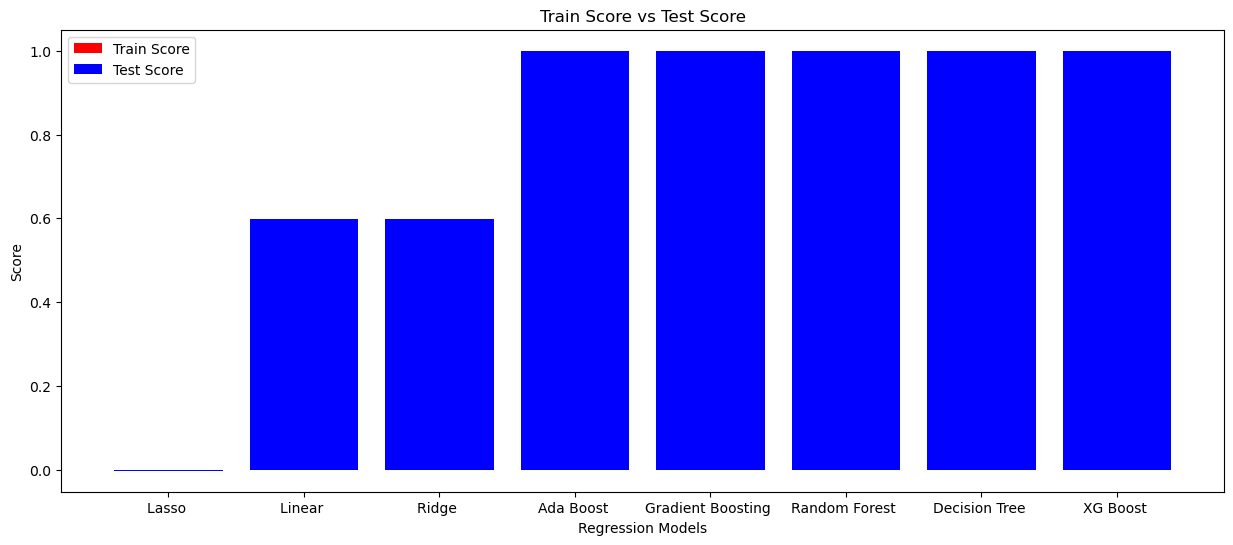

In [71]:
plt.figure(figsize=(15, 6))
plt.bar(x=["Lasso ", "Linear ", "Ridge ", "Ada Boost ", "Gradient Boosting ", "Random Forest ", "Decision Tree ", "XG Boost "], height=[lasso_train_score, lr_train_score, ridge_train_score, abr_train_score, gbr_train_score, rfr_train_score, dtr_train_score, xgb_train_score], color="red", label="Train Score")
plt.bar(x=["Lasso ", "Linear ", "Ridge ", "Ada Boost ", "Gradient Boosting ", "Random Forest ", "Decision Tree ", "XG Boost "], height=[lasso_test_score, lr_test_score, ridge_test_score, abr_test_score, gbr_test_score, rfr_test_score, dtr_test_score, xgb_test_score], color="blue", label="Test Score")
plt.legend()
plt.title("Train Score vs Test Score")
plt.xlabel("Regression Models")
plt.ylabel("Score")
plt.show()


Epoch 1/50
45/45 [==============================] - 3s 23ms/step - loss: 0.0492
Epoch 2/50
45/45 [==============================] - 1s 24ms/step - loss: 0.0188
Epoch 3/50
45/45 [==============================] - 1s 25ms/step - loss: 0.0155
Epoch 4/50
45/45 [==============================] - 1s 24ms/step - loss: 0.0141
Epoch 5/50
45/45 [==============================] - 1s 24ms/step - loss: 0.0125
Epoch 6/50
45/45 [==============================] - 1s 25ms/step - loss: 0.0113
Epoch 7/50
45/45 [==============================] - 1s 24ms/step - loss: 0.0109
Epoch 8/50
45/45 [==============================] - 1s 27ms/step - loss: 0.0106
Epoch 9/50
45/45 [==============================] - 1s 25ms/step - loss: 0.0097
Epoch 10/50
45/45 [==============================] - 1s 29ms/step - loss: 0.0096
Epoch 11/50
45/45 [==============================] - 1s 28ms/step - loss: 0.0088
Epoch 12/50
45/45 [==============================] - 1s 29ms/step - loss: 0.0085
Epoch 13/50
45/45 [==================

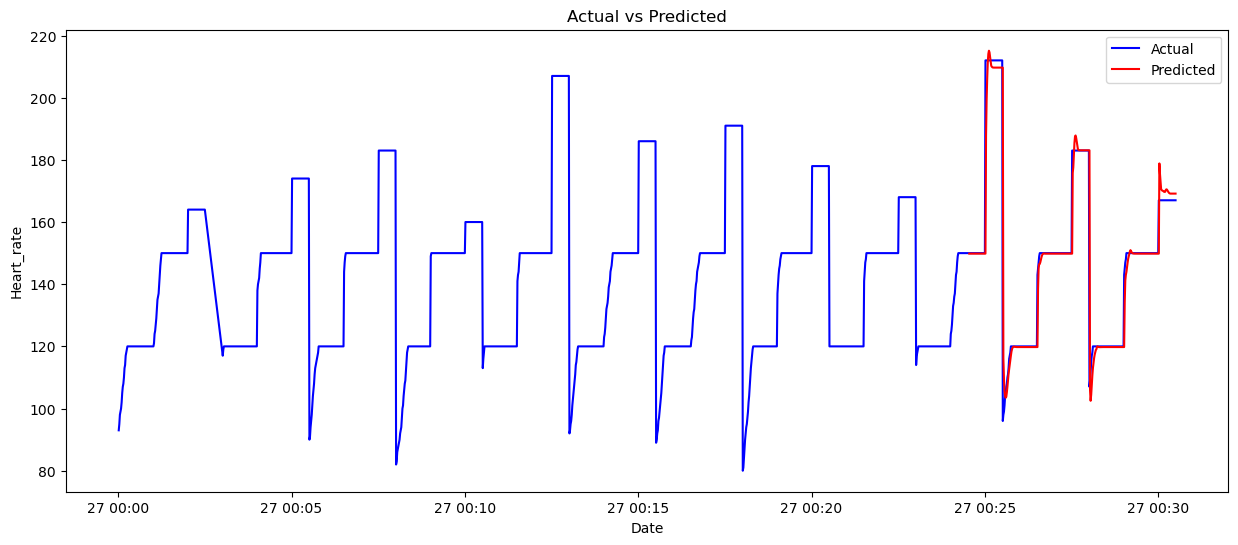

In [84]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming you already have the DataFrame 'df' with the given structure

# Convert the timestamp index to datetime
df.index = pd.to_datetime(df.index)

# Normalize the data
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df.values)

# Split the data into input (X) and output (y) sequences
sequence_length = 10  # Number of previous time steps to consider for each prediction
X = []
y = []
for i in range(sequence_length, len(normalized_data)):
    X.append(normalized_data[i-sequence_length:i])
    y.append(normalized_data[i])

X = np.array(X)
y = np.array(y)

# Split the data into training and testing sets
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(128))
model.add(Dropout(0.2))
model.add(Dense(y.shape[1]))  # Output layer with the same number of features as y

# Compile and train the model
model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print("Test loss:", loss)

# Make predictions
predictions = model.predict(X_test)

# Rescale the predictions back to the original range
predictions = scaler.inverse_transform(predictions)

# Convert the predictions to a DataFrame with timestamp index
prediction_df = pd.DataFrame(predictions, columns=df.columns)
prediction_df.index = df.index[train_size+sequence_length:]

# Print the predicted vitals
print(prediction_df)

# Calculate scoring metrics
mse = mean_squared_error(df.iloc[train_size+sequence_length:], prediction_df)
mae = mean_absolute_error(df.iloc[train_size+sequence_length:], prediction_df)
r2 = r2_score(df.iloc[train_size+sequence_length:], prediction_df)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2) Score:", r2)

# Plot the predicted vs actual
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Heart_rate'], label='Actual', color='blue')
plt.plot(prediction_df.index, prediction_df['Heart_rate'], label='Predicted', color='red')
plt.legend()
plt.title("Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Heart_rate")
plt.show()


